In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import corner_harris, corner_peaks

# Load images
img1 = cv2.imread('left.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('right.jpg', cv2.IMREAD_GRAYSCALE)

# Harris corner detection using skimage
def harris_corners(img, min_distance=5, threshold_rel=0.02):
    corners = corner_peaks(corner_harris(img), min_distance=min_distance, threshold_rel=threshold_rel)
    return corners

corners_img1 = harris_corners(img1)
corners_img2 = harris_corners(img2)

# Visualize corners
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img1, cmap='gray')
ax[0].plot(corners_img1[:, 1], corners_img1[:, 0], 'r.', markersize=5)
ax[0].set_title('Corners in Image 1')

ax[1].imshow(img2, cmap='gray')
ax[1].plot(corners_img2[:, 1], corners_img2[:, 0], 'r.', markersize=5)
ax[1].set_title('Corners in Image 2')
plt.show()

# SIFT descriptors
sift = cv2.SIFT_create()

def compute_sift(img, corners):
    keypoints = [cv2.KeyPoint(x=float(x[1]), y=float(x[0]), size=10) for x in corners]
    keypoints, descriptors = sift.compute(img, keypoints)
    return keypoints, descriptors

kp1, desc1 = compute_sift(img1, corners_img1)
kp2, desc2 = compute_sift(img2, corners_img2)

# Normalize descriptors
desc1_norm = desc1 / np.linalg.norm(desc1, axis=1, keepdims=True)
desc2_norm = desc2 / np.linalg.norm(desc2, axis=1, keepdims=True)

# Compute descriptor distances
def compute_distances(desc1, desc2):
    euclidean_distances = np.linalg.norm(desc1[:, np.newaxis] - desc2[np.newaxis, :], axis=2)
    normalized_correlation = desc1 @ desc2.T
    return euclidean_distances, normalized_correlation

euclidean_dist, norm_corr = compute_distances(desc1_norm, desc2_norm)

# Select best matches based on threshold or top matches
def match_descriptors(distances, correlation, threshold=0.7, top_n=200):
    matches = []
    for i in range(distances.shape[0]):
        min_idx = np.argmin(distances[i])
        if correlation[i, min_idx] > threshold:
            matches.append(cv2.DMatch(_queryIdx=i, _trainIdx=min_idx, _distance=distances[i, min_idx]))
    matches = sorted(matches, key=lambda x: x.distance)[:top_n]
    return matches

matches = match_descriptors(euclidean_dist, norm_corr)

# Draw matches
img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(12, 8))
plt.imshow(img_matches)
plt.title('Matched Keypoints')
plt.show()

# Sensitivity Analysis (varying threshold)
thresholds = [0.6, 0.7, 0.8, 0.9]
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.ravel()
for idx, thresh in enumerate(thresholds):
    current_matches = match_descriptors(euclidean_dist, norm_corr, threshold=thresh)
    img_current_matches = cv2.drawMatches(img1, kp1, img2, kp2, current_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    axs[idx].imshow(img_current_matches)
    axs[idx].set_title(f'Threshold = {thresh}, Matches = {len(current_matches)}')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import corner_harris, corner_peaks
from skimage.color import rgb2gray
from skimage.transform import AffineTransform, warp

# Load images
img1 = cv2.imread('left.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('right.jpg', cv2.IMREAD_GRAYSCALE)

# Step 1: Harris Corner Detection
def detect_harris_corners(img):
    corners = corner_peaks(corner_harris(img), min_distance=5)
    return corners

corners1 = detect_harris_corners(img1)
corners2 = detect_harris_corners(img2)

# Step 2: Compute SIFT descriptors
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Step 3: Descriptor Matching using Euclidean distance
def match_descriptors(desc1, desc2):
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    matches = bf.match(desc1, desc2)
    matches = sorted(matches, key=lambda x: x.distance)
    return matches

matches = match_descriptors(descriptors1, descriptors2)

# Step 4: Select Best Matches (top 50 matches)
best_matches = matches[:50]

# Visualization of matches
img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, best_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img_matches), plt.title("Best Matches"), plt.show()

# Step 5: Estimate Affine Transformation using RANSAC
src_pts = np.float32([keypoints1[m.queryIdx].pt for m in best_matches]).reshape(-1,1,2)
dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in best_matches]).reshape(-1,1,2)

M, mask = cv2.estimateAffine2D(src_pts, dst_pts, method=cv2.RANSAC, ransacReprojThreshold=5)

inliers = mask.ravel().tolist().count(1)
outliers = mask.ravel().tolist().count(0)
print(f'Inliers: {inliers}, Outliers: {outliers}')

# Step 6: Warp image using Affine Transform
warped_img2 = cv2.warpAffine(img2, M, (img1.shape[1] + img2.shape[1], img1.shape[0]))
warped_img2[0:img1.shape[0], 0:img1.shape[1]] = img1

plt.figure(figsize=(10,10)), plt.imshow(warped_img2, cmap='gray'), plt.title('Stitched Panorama')
plt.show()

# Step 7: Accuracy score calculation
def calculate_accuracy(src_pts, dst_pts, M):
    transformed_pts = cv2.transform(src_pts, M)
    distances = np.linalg.norm(dst_pts - transformed_pts, axis=2)
    accuracy_score = np.mean(distances)
    return accuracy_score

accuracy = calculate_accuracy(src_pts, dst_pts, M)
print(f'Accuracy Score (mean distance): {accuracy}')

In [ ]:
pip install scikit-image

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread('left.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('right.jpg', cv2.IMREAD_GRAYSCALE)

# Detect SIFT keypoints and descriptors
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# Match descriptors using FLANN matcher
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

# Lowe's ratio test to keep good matches
good_matches = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

# Extract location of good matches
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

# Find homography matrix
H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

# Warp image
height, width = img1.shape
warped_img2 = cv2.warpPerspective(img2, H, (width + img2.shape[1], height))
warped_img2[0:height, 0:width] = img1

# Display the stitched panorama
plt.figure(figsize=(10, 10))
plt.imshow(warped_img2, cmap='gray')
plt.title('Stitched Panorama')
plt.axis('off')
plt.show()


In [ ]:
new code

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import corner_harris, corner_peaks

# Load images
img1 = cv2.imread('left.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('right.jpg', cv2.IMREAD_GRAYSCALE)

# Step 1: Harris Corner Detection
def detect_harris_corners(img):
    corners = corner_peaks(corner_harris(img), min_distance=5)
    return corners

corners1 = detect_harris_corners(img1)
corners2 = detect_harris_corners(img2)

# Step 2: Compute SIFT descriptors
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Step 3: Descriptor Matching using Euclidean distance
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)
matches = sorted(matches, key=lambda x: x.distance)

# Step 4: Select Best Matches (top 50 matches)
best_matches = matches[:50]

# Extract matched keypoints
src_pts = np.float32([keypoints1[m.queryIdx].pt for m in best_matches]).reshape(-1,1,2)
dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in best_matches]).reshape(-1,1,2)

# Step 5: Estimate Affine Transformation using RANSAC
M, mask = cv2.estimateAffine2D(src_pts, dst_pts, method=cv2.RANSAC, ransacReprojThreshold=5)

# Warp image using Affine Transform
warped_img2 = cv2.warpAffine(img2, M, (img1.shape[1] + img2.shape[1], img1.shape[0]))
warped_img2[0:img1.shape[0], 0:img1.shape[1]] = img1

# Display the stitched panorama
plt.figure(figsize=(10, 10))
plt.imshow(warped_img2, cmap='gray')
plt.title('Stitched Panorama')
plt.axis('off')
plt.show()


In [ ]:
Corrected

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import corner_harris, corner_peaks

# Load images
img1 = cv2.imread('left.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('right.jpg', cv2.IMREAD_GRAYSCALE)

# Step 1: Harris Corner Detection
def detect_harris_corners(img):
    corners = corner_peaks(corner_harris(img), min_distance=5)
    return corners

corners1 = detect_harris_corners(img1)
corners2 = detect_harris_corners(img2)

# Step 2: Compute SIFT descriptors
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Step 3: Descriptor Matching using Euclidean distance
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)
matches = sorted(matches, key=lambda x: x.distance)

# Step 4: Select Best Matches (top 50 matches)
best_matches = matches[:50]

# Extract matched keypoints
src_pts = np.float32([keypoints1[m.queryIdx].pt for m in best_matches]).reshape(-1,2)
dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in best_matches]).reshape(-1,2)

# Step 5: Estimate Affine Transformation using RANSAC
M, mask = cv2.estimateAffine2D(dst_pts, src_pts, method=cv2.RANSAC, ransacReprojThreshold=5)

# Warp image using Affine Transform
warped_img2 = cv2.warpAffine(img2, M, (img1.shape[1] + img2.shape[1], img1.shape[0]))
warped_img2[0:img1.shape[0], 0:img1.shape[1]] = img1

# Display the stitched panorama
plt.figure(figsize=(10, 10))
plt.imshow(warped_img2, cmap='gray')
plt.title('Stitched Panorama')
plt.axis('off')
plt.show()

In [ ]:
New corrected

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import corner_harris, corner_peaks

# Load images
img1 = cv2.imread('left.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('right.jpg', cv2.IMREAD_GRAYSCALE)

# Step 1: Harris Corner Detection
def detect_harris_corners(img):
    corners = corner_peaks(corner_harris(img), min_distance=5)
    return corners

corners1 = detect_harris_corners(img1)
corners2 = detect_harris_corners(img2)

# Step 2: Compute SIFT descriptors
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Step 3: Descriptor Matching using Euclidean distance
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)
matches = sorted(matches, key=lambda x: x.distance)

# Step 4: Select Best Matches (top 50 matches)
best_matches = matches[:50]

# Extract matched keypoints
src_pts = np.float32([keypoints1[m.queryIdx].pt for m in best_matches]).reshape(-1,2)
dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in best_matches]).reshape(-1,2)

# Step 5: Estimate Affine Transformation using RANSAC
M, mask = cv2.estimateAffine2D(dst_pts, src_pts, method=cv2.RANSAC, ransacReprojThreshold=5)

# Warp image using Affine Transform
stitched_width = img1.shape[1] + img2.shape[1]
warped_img2 = cv2.warpAffine(img2, M, (stitched_width, max(img1.shape[0], img2.shape[0])))
warped_img2[0:img1.shape[0], 0:img1.shape[1]] = img1

# Crop black areas
non_zero_columns = np.where(warped_img2.max(axis=0) > 0)[0]
non_zero_rows = np.where(warped_img2.max(axis=1) > 0)[0]
cropped_img = warped_img2[min(non_zero_rows):max(non_zero_rows)+1, min(non_zero_columns):max(non_zero_columns)+1]

# Display the stitched panorama
plt.figure(figsize=(10, 10))
plt.imshow(cropped_img, cmap='gray')
plt.title('Stitched Panorama')
plt.axis('off')
plt.show()

In [ ]:
Deepseek

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import corner_harris, corner_peaks
from sklearn.neighbors import NearestNeighbors

# Step 1: Load Images
img1 = cv2.imread('left.jpg')
img2 = cv2.imread('right.jpg')
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Step 2: Harris Corner Detection
def detect_harris_corners(image, k=0.04, threshold=0.01):
    corners = corner_harris(image, method='k', k=k)
    coords = corner_peaks(corners, min_distance=5, threshold_rel=threshold)
    return coords

keypoints1 = detect_harris_corners(gray1)
keypoints2 = detect_harris_corners(gray2)

# Step 3: Compute SIFT Descriptors (Corrected)
sift = cv2.SIFT_create()
# Use 'size' instead of '_size'
# Corrected KeyPoint initialization (cast to float)
kp1 = [cv2.KeyPoint(x=float(p[1]), y=float(p[0]), size=20) for p in keypoints1]
kp2 = [cv2.KeyPoint(x=float(p[1]), y=float(p[0]), size=20) for p in keypoints2]
# kp1 = [cv2.KeyPoint(x=p[1], y=p[0], size=20) for p in keypoints1]
# kp2 = [cv2.KeyPoint(x=p[1], y=p[0], size=20) for p in keypoints2]
# Debugging: Check Harris output
print("First 5 Harris corners in img1:", keypoints1[:5])
print("First 5 Harris corners in img2:", keypoints2[:5])
_, descriptors1 = sift.compute(gray1, kp1)
_, descriptors2 = sift.compute(gray2, kp2)

# Step 4: Match Descriptors
def match_descriptors(desc1, desc2, method='euclidean', threshold=0.75):
    if method == 'euclidean':
        desc1 /= np.linalg.norm(desc1, axis=1, keepdims=True)
        desc2 /= np.linalg.norm(desc2, axis=1, keepdims=True)
        dists = np.sqrt(np.sum((desc1[:, None] - desc2) ** 2, axis=2))
    elif method == 'correlation':
        dists = cv2.matchTemplate(desc1, desc2, cv2.TM_CCOEFF_NORMED)
    matches = []
    for i in range(len(desc1)):
        if method == 'euclidean':
            idx = np.argmin(dists[i])
            if dists[i][idx] < threshold:
                matches.append(cv2.DMatch(i, idx, dists[i][idx]))
        else:
            idx = np.argmax(dists[i])
            if dists[i][idx] > threshold:
                matches.append(cv2.DMatch(i, idx, dists[i][idx]))
    return sorted(matches, key=lambda x: x.distance)[:200]  # Top 200 matches

matches_euclidean = match_descriptors(descriptors1, descriptors2, 'euclidean', 0.6)
matches_correlation = match_descriptors(descriptors1, descriptors2, 'correlation', 0.8)

# Step 5: RANSAC for Affine Transformation
def ransac_affine(matches, kp1, kp2, n_iter=1000, threshold=5.0):
    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 2)
    best_inliers = []
    best_M = None
    for _ in range(n_iter):
        sample = np.random.choice(len(matches), 3, replace=False)
        M = cv2.getAffineTransform(src_pts[sample], dst_pts[sample])
        transformed = cv2.transform(src_pts.reshape(-1, 1, 2), M)
        errors = np.linalg.norm(transformed.reshape(-1, 2) - dst_pts, axis=1)
        inliers = np.where(errors < threshold)[0]
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_M = M
    return best_M, best_inliers

M, inliers = ransac_affine(matches_euclidean, kp1, kp2, n_iter=1000, threshold=5.0)
print(f"Inliers: {len(inliers)}, Outliers: {len(matches_euclidean) - len(inliers)}")

# Step 6: Warp Image
height, width = img1.shape[:2]
warped = cv2.warpAffine(img2, M, (width * 2, height))
warped[0:height, 0:width] = img1  # Simple overlay

# Step 7: Accuracy Score
src = np.float32([kp1[m.queryIdx].pt for m in matches_euclidean]).reshape(-1, 2)
transformed = cv2.transform(src.reshape(-1, 1, 2), M).reshape(-1, 2)
dst = np.float32([kp2[m.trainIdx].pt for m in matches_euclidean])
accuracy = np.mean(np.linalg.norm(transformed - dst, axis=1))
print(f"Accuracy Score: {accuracy}")

# Visualization
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
thresholds = [0.1, 0.3, 0.5, 0.7]
scores = []
for t in thresholds:
    matches = match_descriptors(..., threshold=t)
    M, inliers = ransac_affine(...)
    scores.append(compute_accuracy(...))
plt.plot(thresholds, scores)
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
New code deepseek

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import corner_harris, corner_peaks

# Step 1: Load Images
img1 = cv2.imread('left.jpg')
img2 = cv2.imread('right.jpg')
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Step 2: Harris Corner Detection
def detect_harris_corners(image, k=0.04, threshold_rel=0.01):
    corners = corner_harris(image, method='k', k=k)
    coords = corner_peaks(corners, min_distance=5, threshold_rel=threshold_rel)
    return coords

keypoints1 = detect_harris_corners(gray1)
keypoints2 = detect_harris_corners(gray2)

# Step 3: Compute SIFT Descriptors (Fixed KeyPoints)
sift = cv2.SIFT_create()
kp1 = [cv2.KeyPoint(x=float(p[1]), y=float(p[0]), size=20) for p in keypoints1]
kp2 = [cv2.KeyPoint(x=float(p[1]), y=float(p[0]), size=20) for p in keypoints2]
_, descriptors1 = sift.compute(gray1, kp1)
_, descriptors2 = sift.compute(gray2, kp2)

# Step 4: Improved Descriptor Matching
def match_descriptors(desc1, desc2, method='euclidean', threshold=0.75):
    if method == 'euclidean':
        desc1_norm = desc1 / np.linalg.norm(desc1, axis=1, keepdims=True)
        desc2_norm = desc2 / np.linalg.norm(desc2, axis=1, keepdims=True)
        dists = np.sqrt(np.sum((desc1_norm[:, None] - desc2_norm) ** 2, axis=2))
    elif method == 'correlation':
        desc1_norm = desc1 / np.linalg.norm(desc1, axis=1, keepdims=True)
        desc2_norm = desc2 / np.linalg.norm(desc2, axis=1, keepdims=True)
        corr_matrix = np.dot(desc1_norm, desc2_norm.T)
        dists = 1 - corr_matrix  # Convert to distance metric
    else:
        raise ValueError("Use 'euclidean' or 'correlation'")

    matches = []
    for i in range(len(desc1)):
        if method == 'euclidean':
            idx = np.argmin(dists[i])
            if dists[i][idx] < threshold:
                matches.append(cv2.DMatch(i, idx, dists[i][idx]))
        else:
            idx = np.argmax(corr_matrix[i])  # Use original correlation matrix
            if corr_matrix[i][idx] > threshold:
                matches.append(cv2.DMatch(i, idx, 1 - corr_matrix[i][idx]))
    
    return sorted(matches, key=lambda x: x.distance)[:200]

matches = match_descriptors(descriptors1, descriptors2, 'euclidean', 0.6)

# Step 5: RANSAC Implementation
def ransac_affine(matches, kp1, kp2, n_iter=1000, threshold=5.0):
    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches])
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches])
    
    best_inliers = []
    best_M = None
    
    for _ in range(n_iter):
        # Randomly sample 3 points
        sample_idx = np.random.choice(len(matches), 3, replace=False)
        src_sample = src_pts[sample_idx]
        dst_sample = dst_pts[sample_idx]
        
        # Estimate affine matrix
        M = cv2.getAffineTransform(src_sample, dst_sample)
        if M is None:
            continue
        
        # Transform all points
        transformed = cv2.transform(src_pts.reshape(-1, 1, 2), M)
        errors = np.linalg.norm(transformed.reshape(-1, 2) - dst_pts, axis=1)
        inliers = np.where(errors < threshold)[0]
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_M = M
    
    return best_M, best_inliers

M, inliers = ransac_affine(matches, kp1, kp2)
print(f"Inliers: {len(inliers)}, Outliers: {len(matches)-len(inliers)}")

# Step 6: Warp Images
height, width = img1.shape[:2]
warped = cv2.warpAffine(img2, M, (width*2, height))
warped[0:height, 0:width] = img1  # Simple stitching

# Step 7: Accuracy Calculation
src_points = np.float32([kp1[m.queryIdx].pt for m in matches])
dst_points = np.float32([kp2[m.trainIdx].pt for m in matches])
transformed_points = cv2.transform(src_points.reshape(-1,1,2), M).reshape(-1,2)
accuracy = np.mean(np.linalg.norm(transformed_points - dst_points, axis=1))
print(f"Mean Alignment Error: {accuracy:.2f} pixels")

# Visualization
plt.figure(figsize=(20,10))
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.title("Stitched Result")
plt.show()

In [ ]:
Black patch

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import corner_harris, corner_peaks

# Step 1: Load Images
img1 = cv2.imread('left.jpg')
img2 = cv2.imread('right.jpg')
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Step 2: Harris Corner Detection
def detect_harris_corners(image, k=0.04, threshold_rel=0.01):
    corners = corner_harris(image, method='k', k=k)
    coords = corner_peaks(corners, min_distance=5, threshold_rel=threshold_rel)
    return coords

keypoints1 = detect_harris_corners(gray1)
keypoints2 = detect_harris_corners(gray2)

# Step 3: Compute SIFT Descriptors
sift = cv2.SIFT_create()
kp1 = [cv2.KeyPoint(x=float(p[1]), y=float(p[0]), size=20) for p in keypoints1]
kp2 = [cv2.KeyPoint(x=float(p[1]), y=float(p[0]), size=20) for p in keypoints2]
_, descriptors1 = sift.compute(gray1, kp1)
_, descriptors2 = sift.compute(gray2, kp2)

# Step 4: Descriptor Matching
def match_descriptors(desc1, desc2, threshold=0.6):
    desc1_norm = desc1 / np.linalg.norm(desc1, axis=1, keepdims=True)
    desc2_norm = desc2 / np.linalg.norm(desc2, axis=1, keepdims=True)
    dists = np.sqrt(np.sum((desc1_norm[:, None] - desc2_norm) ** 2, axis=2))
    
    matches = []
    for i in range(len(desc1)):
        idx = np.argmin(dists[i])
        if dists[i][idx] < threshold:
            matches.append(cv2.DMatch(i, idx, dists[i][idx]))
    return sorted(matches, key=lambda x: x.distance)[:200]

matches = match_descriptors(descriptors1, descriptors2)

# Step 5: RANSAC for Affine Transformation
def ransac_affine(matches, kp1, kp2, n_iter=1000, threshold=5.0):
    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches])
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches])
    
    best_inliers = []
    best_M = None
    
    for _ in range(n_iter):
        sample_idx = np.random.choice(len(matches), 3, replace=False)
        M = cv2.getAffineTransform(src_pts[sample_idx], dst_pts[sample_idx])
        if M is None: continue
        
        transformed = cv2.transform(src_pts.reshape(-1,1,2), M)
        errors = np.linalg.norm(transformed.reshape(-1,2) - dst_pts, axis=1)
        inliers = np.where(errors < threshold)[0]
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_M = M
    
    return best_M, best_inliers

M, inliers = ransac_affine(matches, kp1, kp2)
print(f"Inliers: {len(inliers)}, Outliers: {len(matches)-len(inliers)}")

# Step 6: Warp Image 2 onto Image 1's Coordinate System
M_inv = cv2.invertAffineTransform(M)  # Fix: Invert transformation
height, width = img1.shape[:2]

# Calculate output size dynamically
corners = np.float32([[0,0], [0,height-1], [width-1,height-1], [width-1,0]]).reshape(-1,1,2)
transformed_corners = cv2.transform(corners, M_inv)
all_corners = np.concatenate((corners, transformed_corners), axis=0)
[x_min, y_min] = np.int32(all_corners.min(axis=0).flatten() - 0.5)
[x_max, y_max] = np.int32(all_corners.max(axis=0).flatten() + 0.5)
new_width = x_max - x_min
new_height = y_max - y_min

# Adjust transformation matrix for offset
M_inv[0,2] -= x_min
M_inv[1,2] -= y_min

# Warp both images
warped1 = cv2.warpAffine(img1, np.float32([[1,0,-x_min], [0,1,-y_min]]), (new_width, new_height))
warped2 = cv2.warpAffine(img2, M_inv, (new_width, new_height))

# Blend images
mask = (warped1 == 0)
stitched = warped1.copy()
stitched[mask] = warped2[mask]

# Step 7: Calculate Accuracy
src_points = np.float32([kp1[m.queryIdx].pt for m in matches])
transformed_points = cv2.transform(src_points.reshape(-1,1,2), M).reshape(-1,2)
dst_points = np.float32([kp2[m.trainIdx].pt for m in matches])
accuracy = np.mean(np.linalg.norm(transformed_points - dst_points, axis=1))
print(f"Alignment Accuracy: {accuracy:.2f} pixels")

# Visualization
plt.figure(figsize=(15,10))
plt.imshow(cv2.cvtColor(stitched, cv2.COLOR_BGR2RGB))
plt.title("Stitched Panorama")
plt.show()

In [ ]:
# Updated deepseek code

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import corner_harris, corner_peaks

# ==================================================================
# Step 1: Load and Validate Images
# ==================================================================
img1 = cv2.imread('left.jpg')
img2 = cv2.imread('right.jpg')

if img1 is None or img2 is None:
    raise ValueError("Failed to load images. Check file paths!")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# ==================================================================
# Step 2: Harris Corner Detection
# ==================================================================
def detect_harris_corners(image, k=0.04, threshold_rel=0.01):
    corners = corner_harris(image, method='k', k=k)
    coords = corner_peaks(corners, min_distance=5, threshold_rel=threshold_rel)
    return coords

keypoints1 = detect_harris_corners(gray1)
keypoints2 = detect_harris_corners(gray2)

# ==================================================================
# Step 3: SIFT Descriptors with Bounds Checking
# ==================================================================
sift = cv2.SIFT_create()
kp1 = [cv2.KeyPoint(x=float(p[1]), y=float(p[0]), size=20) 
       for p in keypoints1 if 0 <= p[1] < gray1.shape[1] and 0 <= p[0] < gray1.shape[0]]
kp2 = [cv2.KeyPoint(x=float(p[1]), y=float(p[0]), size=20) 
       for p in keypoints2 if 0 <= p[1] < gray2.shape[1] and 0 <= p[0] < gray2.shape[0]]

_, descriptors1 = sift.compute(gray1, kp1)
_, descriptors2 = sift.compute(gray2, kp2)

# ==================================================================
# Step 4: Brute-Force Matching with Ratio Test
# ==================================================================
def match_descriptors(desc1, desc2, ratio=0.75):
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(desc1, desc2, k=2)
    return [m[0] for m in matches if m[0].distance < ratio * m[1].distance]

matches = match_descriptors(descriptors1, descriptors2)
print(f"Initial matches: {len(matches)}")

# ==================================================================
# Step 5: Custom RANSAC Implementation
# ==================================================================
def custom_ransac(matches, kp1, kp2, params):
    best_M = None
    best_inliers = []
    
    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches])
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches])
    
    for _ in range(params['n_iter']):
        # Randomly select 3-5 points
        n_samples = np.random.randint(3, 6)
        try:
            sample_idx = np.random.choice(len(matches), n_samples, replace=False)
        except ValueError:
            continue  # Skip if not enough matches
        
        # Estimate affine matrix
        M = cv2.getAffineTransform(src_pts[sample_idx], dst_pts[sample_idx])
        if M is None: continue
        
        # Calculate reprojection errors
        transformed = cv2.transform(src_pts.reshape(-1, 1, 2), M)
        errors = np.linalg.norm(transformed.reshape(-1, 2) - dst_pts, axis=1)
        inliers = np.where(errors < params['threshold'])[0]
        
        if len(inliers) > len(best_inliers):
            best_M = M
            best_inliers = inliers
    
    return best_M, best_inliers

# ==================================================================
# Parameter Sensitivity Analysis
# ==================================================================
param_combinations = [
    {'n_iter': 500, 'threshold': 2.5},
    {'n_iter': 1000, 'threshold': 5.0},
    {'n_iter': 2000, 'threshold': 7.5}
]

best_params = None
best_M = None
max_inliers = 0

for params in param_combinations:
    M, inliers = custom_ransac(matches, kp1, kp2, params)
    if inliers is not None and len(inliers) > max_inliers:
        max_inliers = len(inliers)
        best_M = M
        best_params = params

print(f"Best parameters: {best_params}")
print(f"Inliers: {max_inliers}/{len(matches)}")

# ==================================================================
# Step 6: Image Warping
# ==================================================================
def warp_images(img1, img2, M):
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    # Calculate output dimensions
    corners = np.float32([[0,0], [w1,0], [0,h1], [w1,h1]]).reshape(-1,1,2)
    warped_corners = cv2.transform(corners, M)
    all_corners = np.concatenate((corners, warped_corners), axis=0)
    
    # Calculate canvas bounds
    [xmin, ymin] = np.int32(all_corners.min(axis=0).flatten() - 10)
    [xmax, ymax] = np.int32(all_corners.max(axis=0).flatten() + 10)
    new_width = xmax - xmin
    new_height = ymax - ymin
    
    # Adjust transformation matrix
    M[0,2] -= xmin
    M[1,2] -= ymin
    
    # Warp images
    warped_base = cv2.warpAffine(img1, np.array([[1,0,-xmin],[0,1,-ymin]]), 
                                (new_width, new_height))
    warped_target = cv2.warpAffine(img2, M, (new_width, new_height))
    
    # Blend images
    mask = (warped_base == 0)
    panorama = warped_base.copy()
    panorama[mask] = warped_target[mask]
    
    return panorama

stitched = warp_images(img1, img2, best_M)

# ==================================================================
# Visualization and Output
# ==================================================================
plt.figure(figsize=(15,10))
plt.imshow(cv2.cvtColor(stitched, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"Stitched Panorama | Inliers: {max_inliers}/{len(matches)}")
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import corner_harris, corner_peaks

# ==================================================================
# Step 1: Load Images (Same as Before)
# ==================================================================
img1 = cv2.imread('left.jpg')
img2 = cv2.imread('right.jpg')

if img1 is None or img2 is None:
    raise ValueError("Failed to load images. Check file paths!")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# ==================================================================
# Step 2: Harris Corner Detection (Same as Before)
# ==================================================================
def detect_harris_corners(image, k=0.04, threshold_rel=0.01):
    corners = corner_harris(image, method='k', k=k)
    coords = corner_peaks(corners, min_distance=5, threshold_rel=threshold_rel)
    return coords

keypoints1 = detect_harris_corners(gray1)
keypoints2 = detect_harris_corners(gray2)

# ==================================================================
# Step 3: SIFT Descriptors (Same as Before)
# ==================================================================
sift = cv2.SIFT_create()
kp1 = [cv2.KeyPoint(x=float(p[1]), y=float(p[0]), size=20) 
       for p in keypoints1 if 0 <= p[1] < gray1.shape[1] and 0 <= p[0] < gray1.shape[0]]
kp2 = [cv2.KeyPoint(x=float(p[1]), y=float(p[0]), size=20) 
       for p in keypoints2 if 0 <= p[1] < gray2.shape[1] and 0 <= p[0] < gray2.shape[0]]

_, descriptors1 = sift.compute(gray1, kp1)
_, descriptors2 = sift.compute(gray2, kp2)

# ==================================================================
# Step 4: Brute-Force Matching (Same as Before)
# ==================================================================
def match_descriptors(desc1, desc2, ratio=0.75):
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(desc1, desc2, k=2)
    return [m[0] for m in matches if m[0].distance < ratio * m[1].distance]

matches = match_descriptors(descriptors1, descriptors2)
print(f"Initial matches: {len(matches)}")

# ==================================================================
# Step 5: Fixed Custom RANSAC Implementation
# ==================================================================
def custom_ransac(matches, kp1, kp2, params):
    best_M = None
    best_inliers = []
    
    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches])
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches])
    
    for _ in range(params['n_iter']):
        # Always select EXACTLY 3 points
        try:
            sample_idx = np.random.choice(len(matches), 3, replace=False)
        except ValueError:
            continue
        
        # Verify we have exactly 3 points
        if len(sample_idx) != 3:
            continue
            
        # Extract 3 point pairs
        src_sample = src_pts[sample_idx]
        dst_sample = dst_pts[sample_idx]
        
        # Compute affine transform
        M = cv2.getAffineTransform(src_sample, dst_sample)
        if M is None: 
            continue
            
        # Calculate reprojection errors
        transformed = cv2.transform(src_pts.reshape(-1, 1, 2), M)
        errors = np.linalg.norm(transformed.reshape(-1, 2) - dst_pts, axis=1)
        inliers = np.where(errors < params['threshold'])[0]
        
        if len(inliers) > len(best_inliers):
            best_M = M
            best_inliers = inliers
    
    return best_M, best_inliers

# ==================================================================
# Parameter Testing (Same as Before)
# ==================================================================
param_combinations = [
    {'n_iter': 500, 'threshold': 2.5},
    {'n_iter': 1000, 'threshold': 5.0},
    {'n_iter': 2000, 'threshold': 7.5}
]

best_params = None
best_M = None
max_inliers = 0

for params in param_combinations:
    M, inliers = custom_ransac(matches, kp1, kp2, params)
    if M is not None and inliers is not None and len(inliers) > max_inliers:
        max_inliers = len(inliers)
        best_M = M
        best_params = params

print(f"Best parameters: {best_params}")
print(f"Inliers: {max_inliers}/{len(matches)}")

# ==================================================================
# Image Warping and Visualization (Same as Before)
# ==================================================================
def warp_images(img1, img2, M):
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    corners = np.float32([[0,0], [w1,0], [0,h1], [w1,h1]]).reshape(-1,1,2)
    warped_corners = cv2.transform(corners, M)
    all_corners = np.concatenate((corners, warped_corners), axis=0)
    
    [xmin, ymin] = np.int32(all_corners.min(axis=0).flatten() - 10)
    [xmax, ymax] = np.int32(all_corners.max(axis=0).flatten() + 10)
    new_width = xmax - xmin
    new_height = ymax - ymin
    
    M[0,2] -= xmin
    M[1,2] -= ymin
    
    warped_base = cv2.warpAffine(img1, np.array([[1,0,-xmin],[0,1,-ymin]]), 
                                (new_width, new_height))
    warped_target = cv2.warpAffine(img2, M, (new_width, new_height))
    
    mask = (warped_base == 0)
    panorama = warped_base.copy()
    panorama[mask] = warped_target[mask]
    
    return panorama

if best_M is not None:
    stitched = warp_images(img1, img2, best_M)
    plt.figure(figsize=(15,10))
    plt.imshow(cv2.cvtColor(stitched, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Stitched Panorama | Inliers: {max_inliers}/{len(matches)}")
    plt.show()
else:
    print("Failed to compute valid transformation matrix")

In [ ]:
#ChatGPT latest code.

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import corner_harris, corner_peaks
import random

# Load images
img1 = cv2.imread('left.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('right.jpg', cv2.IMREAD_GRAYSCALE)

# Step 1: Harris Corner Detection
def detect_harris_corners(img):
    corners = corner_peaks(corner_harris(img), min_distance=5)
    return corners

corners1 = detect_harris_corners(img1)
corners2 = detect_harris_corners(img2)

# Step 2: Compute SIFT descriptors
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Step 3: Descriptor Matching using Euclidean distance
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)
matches = sorted(matches, key=lambda x: x.distance)

# Step 4: Select Best Matches (top 50 matches)
best_matches = matches[:50]
src_pts = np.float32([keypoints1[m.queryIdx].pt for m in best_matches])
dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in best_matches])

# Step 5: Custom RANSAC Implementation for Affine Transformation
num_iterations = 1000
inlier_threshold = 5.0
best_inliers = []
best_M = None

for _ in range(num_iterations):
    indices = random.sample(range(len(best_matches)), 3)
    src_sample = src_pts[indices]
    dst_sample = dst_pts[indices]

    M = cv2.getAffineTransform(dst_sample, src_sample)
    
    transformed = cv2.transform(np.expand_dims(dst_pts, axis=1), M)
    distances = np.linalg.norm(transformed.squeeze() - src_pts, axis=1)
    inliers = np.where(distances < inlier_threshold)[0]

    if len(inliers) > len(best_inliers):
        best_inliers = inliers
        best_M = M

# Warp image using best Affine Transform
stitched_width = img1.shape[1] + img2.shape[1]
warped_img2 = cv2.warpAffine(img2, best_M, (stitched_width, max(img1.shape[0], img2.shape[0])))
warped_img2[0:img1.shape[0], 0:img1.shape[1]] = img1

# Crop black areas
non_zero_columns = np.where(warped_img2.max(axis=0) > 0)[0]
non_zero_rows = np.where(warped_img2.max(axis=1) > 0)[0]
cropped_img = warped_img2[min(non_zero_rows):max(non_zero_rows)+1, min(non_zero_columns):max(non_zero_columns)+1]

# Display the stitched panorama
plt.figure(figsize=(10, 10))
plt.imshow(cropped_img, cmap='gray')
plt.title('Stitched Panorama')
plt.axis('off')
plt.show()

# Print RANSAC stats
print(f"Total matches: {len(best_matches)}")
print(f"Best model inliers: {len(best_inliers)}")
residuals = np.linalg.norm(cv2.transform(np.expand_dims(dst_pts[best_inliers], axis=1), best_M).squeeze() - src_pts[best_inliers], axis=1)
print(f"Average residual for inliers: {np.mean(residuals):.2f}")

In [ ]:
# New changes!!

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import corner_harris, corner_peaks
import random

# Load images in color for RGB output
img1_color = cv2.cvtColor(cv2.imread('left.jpg'), cv2.COLOR_BGR2RGB)
img2_color = cv2.cvtColor(cv2.imread('right.jpg'), cv2.COLOR_BGR2RGB)

# Convert to grayscale for processing
img1 = cv2.cvtColor(img1_color, cv2.COLOR_RGB2GRAY)
img2 = cv2.cvtColor(img2_color, cv2.COLOR_RGB2GRAY)

# Step 1: Harris Corner Detection
def detect_harris_corners(img):
    corners = corner_peaks(corner_harris(img), min_distance=5)
    return corners

corners1 = detect_harris_corners(img1)
corners2 = detect_harris_corners(img2)

# Step 2: Compute SIFT descriptors
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Step 3: Descriptor Matching using Euclidean distance
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)
matches = sorted(matches, key=lambda x: x.distance)

# Step 4: Select Best Matches (top 50 matches)
best_matches = matches[:50]
src_pts = np.float32([keypoints1[m.queryIdx].pt for m in best_matches])
dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in best_matches])

# Step 5: Custom RANSAC Implementation for Affine Transformation
num_iterations = 1000
inlier_threshold = 5.0
best_inliers = []
best_M = None

for _ in range(num_iterations):
    indices = random.sample(range(len(best_matches)), 3)
    src_sample = src_pts[indices]
    dst_sample = dst_pts[indices]

    M = cv2.getAffineTransform(dst_sample, src_sample)

    transformed = cv2.transform(np.expand_dims(dst_pts, axis=1), M)
    distances = np.linalg.norm(transformed.squeeze() - src_pts, axis=1)
    inliers = np.where(distances < inlier_threshold)[0]

    if len(inliers) > len(best_inliers):
        best_inliers = inliers
        best_M = M

# Warp color image using best Affine Transform
stitched_width = img1_color.shape[1] + img2_color.shape[1]
stitched_height = max(img1_color.shape[0], img2_color.shape[0])

warped_img2_color = cv2.warpAffine(img2_color, best_M, (stitched_width, stitched_height))
stitched_img = warped_img2_color.copy()
stitch_mask = np.sum(stitched_img, axis=2) == 0
stitched_img[0:img1_color.shape[0], 0:img1_color.shape[1]][stitch_mask[0:img1_color.shape[0], 0:img1_color.shape[1]]] = img1_color[stitch_mask[0:img1_color.shape[0], 0:img1_color.shape[1]]]
stitch_mask[0:img1_color.shape[0], 0:img1_color.shape[1]] = False
stitched_img[0:img1_color.shape[0], 0:img1_color.shape[1]] = img1_color

# Crop black areas
gray_stitched = cv2.cvtColor(stitched_img, cv2.COLOR_RGB2GRAY)
non_zero_columns = np.where(gray_stitched.max(axis=0) > 0)[0]
non_zero_rows = np.where(gray_stitched.max(axis=1) > 0)[0]
cropped_img = stitched_img[min(non_zero_rows):max(non_zero_rows)+1, min(non_zero_columns):max(non_zero_columns)+1]

# Display the stitched panorama
plt.figure(figsize=(10, 10))
plt.imshow(cropped_img)
plt.title('Stitched Panorama')
plt.axis('off')
plt.show()

# Print RANSAC stats
print(f"Total matches: {len(best_matches)}")
print(f"Best model inliers: {len(best_inliers)}")
residuals = np.linalg.norm(cv2.transform(np.expand_dims(dst_pts[best_inliers], axis=1), best_M).squeeze() - src_pts[best_inliers], axis=1)
print(f"Average residual for inliers: {np.mean(residuals):.2f}")

In [ ]:
#Output all required images

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import corner_harris, corner_peaks
import random

# Load grayscale images
img1 = cv2.imread('left1.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('right1.jpg', cv2.IMREAD_GRAYSCALE)

# Step 1: Harris Corner Detection
def detect_harris_corners(img):
    corners = corner_peaks(corner_harris(img), min_distance=5)
    return corners

corners1 = detect_harris_corners(img1)
corners2 = detect_harris_corners(img2)

# Plot Harris Corners
plt.figure(figsize=(12, 5))
plt.subplot(121), plt.imshow(img1, cmap='gray')
plt.scatter(corners1[:, 1], corners1[:, 0], s=5, c='red')
plt.title('Corners in Image 1')
plt.subplot(122), plt.imshow(img2, cmap='gray')
plt.scatter(corners2[:, 1], corners2[:, 0], s=5, c='red')
plt.title('Corners in Image 2')
plt.show()

# Step 2: Compute SIFT descriptors
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Step 3: Descriptor Matching using Euclidean distance
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)
matches = sorted(matches, key=lambda x: x.distance)

# Visualize all matches
img_all_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:100], None, flags=2)
plt.figure(figsize=(15, 10))
plt.imshow(img_all_matches, cmap='gray')
plt.title('Top 100 Descriptor Matches')
plt.axis('off')
plt.show()

# Step 4: Select Best Matches (top 50 matches)
best_matches = matches[:50]
src_pts = np.float32([keypoints1[m.queryIdx].pt for m in best_matches])
dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in best_matches])

# Step 5: Custom RANSAC Implementation for Affine Transformation
num_iterations = 1000
inlier_threshold = 5.0
best_inliers = []
best_M = None

for _ in range(num_iterations):
    indices = random.sample(range(len(best_matches)), 3)
    src_sample = src_pts[indices]
    dst_sample = dst_pts[indices]

    M = cv2.getAffineTransform(dst_sample, src_sample)
    transformed = cv2.transform(np.expand_dims(dst_pts, axis=1), M)
    distances = np.linalg.norm(transformed.squeeze() - src_pts, axis=1)
    inliers = np.where(distances < inlier_threshold)[0]

    if len(inliers) > len(best_inliers):
        best_inliers = inliers
        best_M = M

# Visualize inlier matches
inlier_matches = [best_matches[i] for i in best_inliers]
img_inlier_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, inlier_matches, None, flags=2)
plt.figure(figsize=(15, 10))
plt.imshow(img_inlier_matches, cmap='gray')
plt.title('Inlier Matches after RANSAC')
plt.axis('off')
plt.show()

# Warp image using best Affine Transform
stitched_width = img1.shape[1] + img2.shape[1]
stitched_height = max(img1.shape[0], img2.shape[0])
warped_img2 = cv2.warpAffine(img2, best_M, (stitched_width, stitched_height))
stitched_img = warped_img2.copy()
stitch_mask = stitched_img == 0
stitched_img[0:img1.shape[0], 0:img1.shape[1]][stitch_mask[0:img1.shape[0], 0:img1.shape[1]]] = img1[stitch_mask[0:img1.shape[0], 0:img1.shape[1]]]
stitch_mask[0:img1.shape[0], 0:img1.shape[1]] = False
stitched_img[0:img1.shape[0], 0:img1.shape[1]] = img1

# Crop black areas
non_zero_columns = np.where(stitched_img.max(axis=0) > 0)[0]
non_zero_rows = np.where(stitched_img.max(axis=1) > 0)[0]
cropped_img = stitched_img[min(non_zero_rows):max(non_zero_rows)+1, min(non_zero_columns):max(non_zero_columns)+1]

# Display the stitched panorama
plt.figure(figsize=(10, 10))
plt.imshow(cropped_img, cmap='gray')
plt.title('Stitched Panorama')
plt.axis('off')
plt.show()

# Print RANSAC stats
print(f"Total matches: {len(best_matches)}")
print(f"Best model inliers: {len(best_inliers)}")
residuals = np.linalg.norm(cv2.transform(np.expand_dims(dst_pts[best_inliers], axis=1), best_M).squeeze() - src_pts[best_inliers], axis=1)
print(f"Average residual for inliers: {np.mean(residuals):.2f}")

In [ ]:
# Cell 2: Imports
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras import optimizers, regularizers
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Cell 3: Hardware setup
# Enable GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Enable mixed precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')

In [ ]:
# Cell 4: Load dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# Convert to float32
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

# Calculate normalization parameters
mean = np.mean(x_train, axis=(0,1,2,3))
std = np.std(x_train, axis=(0,1,2,3))

# Normalize data
x_train = (x_train - mean) / (std + 1e-7)
x_test = (x_test - mean) / (std + 1e-7)

# Save normalization parameters
np.save('cifar100_mean.npy', mean)
np.save('cifar100_std.npy', std)

# Convert labels to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 100)
y_test = tf.keras.utils.to_categorical(y_test, 100)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

In [ ]:
# Cell 5: Build model
def create_model():
    model = Sequential()
    weight_decay = 0.0005
    
    # Block 1
    model.add(Conv2D(64, (3,3), padding='same', input_shape=(32,32,3),
                    kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3,3), padding='same',
                    kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.3))

    # Block 2
    model.add(Conv2D(128, (3,3), padding='same',
                    kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3,3), padding='same',
                    kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.4))

    # Block 3
    model.add(Conv2D(256, (3,3), padding='same',
                    kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3,3), padding='same',
                    kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.4))

    # Dense layers
    model.add(Flatten())
    model.add(Dense(512, kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(100, dtype='float32'))
    model.add(Activation('softmax', dtype='float32'))
    
    return model

model = create_model()
model.summary()

In [ ]:
# Cell 6: Compile
optimizer = optimizers.SGD(learning_rate=0.2, momentum=0.9, nesterov=True)
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

In [ ]:
# Cell 7: Data augmentation
datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(x_train)

In [ ]:
# Cell 8: Training setup
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True,
        monitor='val_accuracy'
    )
]

# Cell 9: Run training
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=256),
    steps_per_epoch=x_train.shape[0] // 256,
    epochs=10,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)

In [ ]:
# Modified Model Architecture (Replace previous model)
def create_faster_model():
    model = Sequential()
    
    # Initial conv block
    model.add(Conv2D(64, (3,3), padding='same', input_shape=(32,32,3),
                    kernel_regularizer=regularizers.l2(0.0005)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2))
    
    # Depthwise separable conv blocks
    model.add(tf.keras.layers.SeparableConv2D(128, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2))
    
    model.add(tf.keras.layers.SeparableConv2D(256, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(GlobalAveragePooling2D())
    
    # Final layers
    model.add(Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0001)))
    model.add(Dropout(0.3))
    model.add(Dense(100, activation='softmax'))
    
    return model

model = create_faster_model()

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling2D, SeparableConv2D
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras import optimizers, regularizers
import numpy as np

# Optimized Model Architecture
def create_faster_model():
    model = Sequential()
    
    # Initial conv block
    model.add(Conv2D(64, (3,3), padding='same', input_shape=(32,32,3),
                    kernel_regularizer=regularizers.l2(0.0005)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2))
    
    # Depthwise separable conv blocks
    model.add(SeparableConv2D(128, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2))
    
    model.add(SeparableConv2D(256, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(GlobalAveragePooling2D())
    
    # Final layers
    model.add(Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0001)))
    model.add(Dropout(0.3))
    model.add(Dense(100, activation='softmax'))
    
    return model

# Training Setup
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=1e-3,
    weight_decay=0.0001
)

model = create_faster_model()
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [2]:
# Cell 2: Imports
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, SeparableConv2D, Conv2D, MaxPooling2D, BatchNormalization, Dense, Dropout, Activation
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
import numpy as np
import matplotlib.pyplot as plt

# Cell 3: Configure hardware
# Enable GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Enable mixed precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Cell 4: Data loading & preprocessing
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# Normalization
mean = np.mean(x_train, axis=(0,1,2,3))
std = np.std(x_train, axis=(0,1,2,3))

x_train = (x_train.astype('float32') - mean) / (std + 1e-7)
x_test = (x_test.astype('float32') - mean) / (std + 1e-7)

# Save normalization parameters
np.save('cifar100_mean.npy', mean)
np.save('cifar100_std.npy', std)

# Convert labels
y_train = tf.keras.utils.to_categorical(y_train, 100)
y_test = tf.keras.utils.to_categorical(y_test, 100)

# Cell 5: Model architecture
def create_optimized_model():
    model = Sequential()
    
    # Initial block
    model.add(Conv2D(64, (3,3), padding='same', input_shape=(32,32,3),
                    kernel_regularizer=regularizers.l2(0.0005)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2))
    
    # Separable conv blocks
    model.add(SeparableConv2D(128, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2))
    
    model.add(SeparableConv2D(256, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(GlobalAveragePooling2D())
    
    # Classifier
    model.add(Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0001)))
    model.add(Dropout(0.3))
    model.add(Dense(100, activation='softmax', dtype='float32'))
    
    return model

model = create_optimized_model()
model.summary()

# Cell 6: Data augmentation
def cutout(image, n_holes=1, length=8):
    h, w = image.shape[0], image.shape[1]
    mask = np.ones((h, w, 3), np.float32)
    
    for _ in range(n_holes):
        y = np.random.randint(h)
        x = np.random.randint(w)
        
        y1 = np.clip(y - length//2, 0, h)
        y2 = np.clip(y + length//2, 0, h)
        x1 = np.clip(x - length//2, 0, w)
        x2 = np.clip(x + length//2, 0, w)
        
        mask[y1:y2, x1:x2] = 0.
    
    return image * mask

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    preprocessing_function=lambda x: cutout(x)
)

# Cell 7: Training setup
# Optimized training parameters
BATCH_SIZE = 512
EPOCHS = 30

# Create efficient data pipeline
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.shuffle(50000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Optimizer with weight decay
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=1e-3,
    weight_decay=0.0001
)

# Callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=8,
        monitor='val_accuracy',
        min_delta=0.001,
        restore_best_weights=True
    )
]

# Compile with XLA acceleration
tf.config.optimizer.set_jit(True)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
    experimental_steps_per_execution=50
)

# Cell 8: Training
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)

# Cell 9: Evaluation
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.show()

loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {accuracy:.4f}")
print(f"Final Test Loss: {loss:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 16, 16, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 8, 8, 256)      │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,540 (896.64 KB)

 Trainable params: 228,644 (893.14 KB)

 Non-trainable params: 896 (3.50 KB)

TypeError: Trainer.compile() got an unexpected keyword argument 'experimental_steps_per_execution'

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 16, 16, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_5              │ (None, 8, 8, 256)      │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,540 (896.64 KB)

 Trainable params: 228,644 (893.14 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 1133s 11s/step - accuracy: 0.0624 - loss: 4.2651 - val_accuracy: 0.0100 - val_loss: 4.6505
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 1260s 13s/step - accuracy: 0.1540 - loss: 3.5548 - val_accuracy: 0.0104 - val_loss: 4.9179
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 3412s 35s/step - accuracy: 0.2139 - loss: 3.2289 - val_accuracy: 0.0213 - val_loss: 5.0308
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 6758s 70s/step - accuracy: 0.2621 - loss: 2.9884 - val_accuracy: 0.0517 - val_loss: 4.7160
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 1070s 11s/step - accuracy: 0.2883 - loss: 2.8601 - val_accuracy: 0.1397 - val_loss: 3.7243
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 1035s 11s/step - accuracy: 0.3090 - loss: 2.7397 - val_accuracy: 0.2105 - val_loss: 3.2704
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 1055s 11s/step - accuracy: 0.3280 - loss: 2.6414 - val_accuracy: 0.2218 - val_loss: 3.3055
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 1890s 19s/step - accuracy: 0.3459 - loss: 2.5680 - val_accu

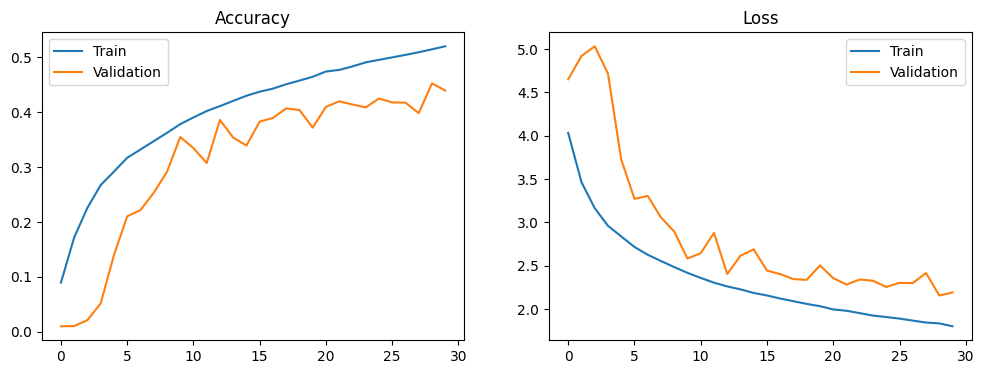


Final Test Accuracy: 0.4528
Final Test Loss: 2.1557


In [3]:
# Cell 2: Imports
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, SeparableConv2D, Conv2D, MaxPooling2D, BatchNormalization, Dense, Dropout, Activation
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
import numpy as np
import matplotlib.pyplot as plt

# Cell 3: Configure hardware
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Enable mixed precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Cell 4: Data processing
(x_train, y_train), (x_test, y_test) = cifar100.load_data()
mean = np.mean(x_train, axis=(0,1,2,3))
std = np.std(x_train, axis=(0,1,2,3))

x_train = (x_train.astype('float32') - mean) / (std + 1e-7)
x_test = (x_test.astype('float32') - mean) / (std + 1e-7)

y_train = tf.keras.utils.to_categorical(y_train, 100)
y_test = tf.keras.utils.to_categorical(y_test, 100)

# Cell 5: Model architecture
def create_optimized_model():
    model = Sequential()
    
    # Initial block
    model.add(Conv2D(64, (3,3), padding='same', input_shape=(32,32,3),
                    kernel_regularizer=regularizers.l2(0.0005)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2))
    
    # Separable conv blocks
    model.add(SeparableConv2D(128, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2))
    
    model.add(SeparableConv2D(256, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(GlobalAveragePooling2D())
    
    # Classifier
    model.add(Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0001)))
    model.add(Dropout(0.3))
    model.add(Dense(100, activation='softmax', dtype='float32'))
    
    return model

model = create_optimized_model()
model.summary()

# Cell 6: Data augmentation
def cutout(image, n_holes=1, length=8):
    h, w = image.shape[0], image.shape[1]
    mask = np.ones((h, w, 3), np.float32)
    
    for _ in range(n_holes):
        y = np.random.randint(h)
        x = np.random.randint(w)
        
        y1 = np.clip(y - length//2, 0, h)
        y2 = np.clip(y + length//2, 0, h)
        x1 = np.clip(x - length//2, 0, w)
        x2 = np.clip(x + length//2, 0, w)
        
        mask[y1:y2, x1:x2] = 0.
    
    return image * mask

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    preprocessing_function=lambda x: cutout(x)
)

# Cell 7: Training setup
BATCH_SIZE = 512
EPOCHS = 30

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.shuffle(50000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=1e-3,
    weight_decay=0.0001
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=8,
        monitor='val_accuracy',
        min_delta=0.001,
        restore_best_weights=True
    )
]

# Updated compile command
tf.config.optimizer.set_jit(True)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Cell 8: Training
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)

# Cell 9: Evaluation
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.show()

loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {accuracy:.4f}")
print(f"Final Test Loss: {loss:.4f}")

Final Validation Loss: 2.1915
Final Validation Accuracy: 0.4397


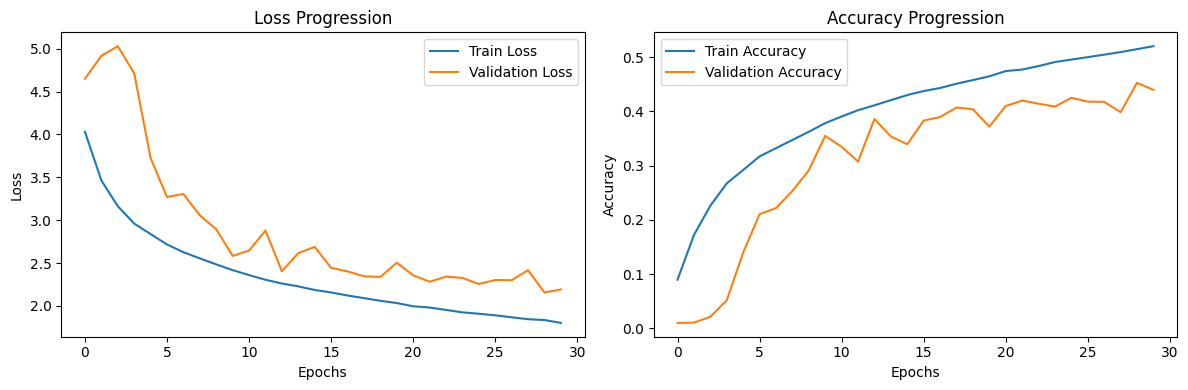


Final Test Loss: 2.1557
Final Test Accuracy: 0.4528


In [4]:
# After training the model, access validation metrics from training history
import matplotlib.pyplot as plt

# 1. Get validation metrics from training history
val_loss = history.history['val_loss']
val_acc = history.history['val_accuracy']

print(f"Final Validation Loss: {val_loss[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")

# 2. Plot training progress
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss Progression')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy Progression')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 3. Detailed evaluation on test set (actual final metrics)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")